In [1]:
import numpy as np
import uproot as up
import awkward as ak
from sklearn.model_selection import train_test_split

from plotting import plot_resolutions, plot_scale_factors
from corrections import bdt, histo

%load_ext autoreload
%autoreload 2


In [2]:
def get_data(path, branch, keys):
    """
    Open file and return as a pd dataframe
    """
    with up.open(path)[branch] as file:
        data = file.arrays( filter_name=list( keys.keys() ) )
        df = ak.to_dataframe(data)
        df.rename(columns=keys, inplace=True)
        df.reset_index(inplace=True, drop=True)
        return df

In [3]:
def get_response(df, eps=1e-3):
    """
    Calculate pT and mass responses
    """
    df["pt_response"] = (df["pt"] + eps) / (df["genpt"] + eps)
    df["mass_response"] = (df["mass"] + eps) / (df["genmass"] + eps)
    return df

In [4]:
def filter_dynamic_range(df):
    """
    Only keep jets within the dynamic range that can be represented by the level-1 types
    """
    mask = (df["genmass"] > 0.) & (df["genmass"] < 181.)
    mask = mask & ( df["genpt"] > 0.) & (df["genpt"] < 2047. )

    mask = mask & ( df["mass"] > 0.) & (df["mass"] < 181. )
    mask = mask & ( df["pt"] > 0.) & (df["pt"] < 2047. )

    mask = mask & (abs(df["eta"]) < 3.)

    return df[mask]

In [5]:
def filter_responses(df):
    """
    Only keep jets with responses in (0.25, 4.0), outside of this range the corrections are unstable
    """
    mask = (df["pt_response"] > 0.25) & (df["pt_response"] < 4.0)
    mask = mask & (df["mass_response"] > 0.25) & (df["mass_response"] < 4.0)
    return df[mask]

In [6]:
path = "./data/sc8Jets.root"
branch = "outnano/Jets"
keys = {"jet_pt": "pt", "jet_eta_phys": "eta", "jet_mass": "mass", "jet_genmatch_pt": "genpt", "jet_genmatch_mass": "genmass", "event": "event"}

# Load data
df = get_data(path, branch, keys)
df = get_response(df)

# Split into train and test
train, test = train_test_split(df, test_size=0.3, random_state=42)

# Only process training data here
train = filter_dynamic_range(train)
train = filter_responses(train)

In [12]:
train

,event,eta,pt,mass,genpt,genmass,pt_response,mass_response
5049729,146440,0.676486,152.50,11.067972,254.714218,43.314732,0.598712,0.255542
6560493,308597,-0.131155,452.50,45.604275,403.925873,66.970375,1.120255,0.680967
955115,70594,0.253107,45.00,9.695360,56.794945,17.056263,0.792328,0.568459
7320194,241150,0.444854,277.00,25.514702,304.699982,43.424339,0.909091,0.587576
4516032,475524,-1.243291,223.50,31.024183,155.473297,34.191429,1.437543,0.907370
...,...,...,...,...,...,...,...,...
4304572,251754,-0.008437,409.25,31.136795,440.296631,45.263641,0.929487,0.687905
1692743,105921,-1.278573,73.25,23.947861,58.005512,11.614013,1.262807,2.061888
6423388,286482,-0.855194,57.50,7.071068,91.203758,24.428871,0.630461,0.289484
6962611,41045,0.759320,200.75,19.300259,228.629089,33.324467,0.878060,0.579174


# Apply histo scale factors to training data

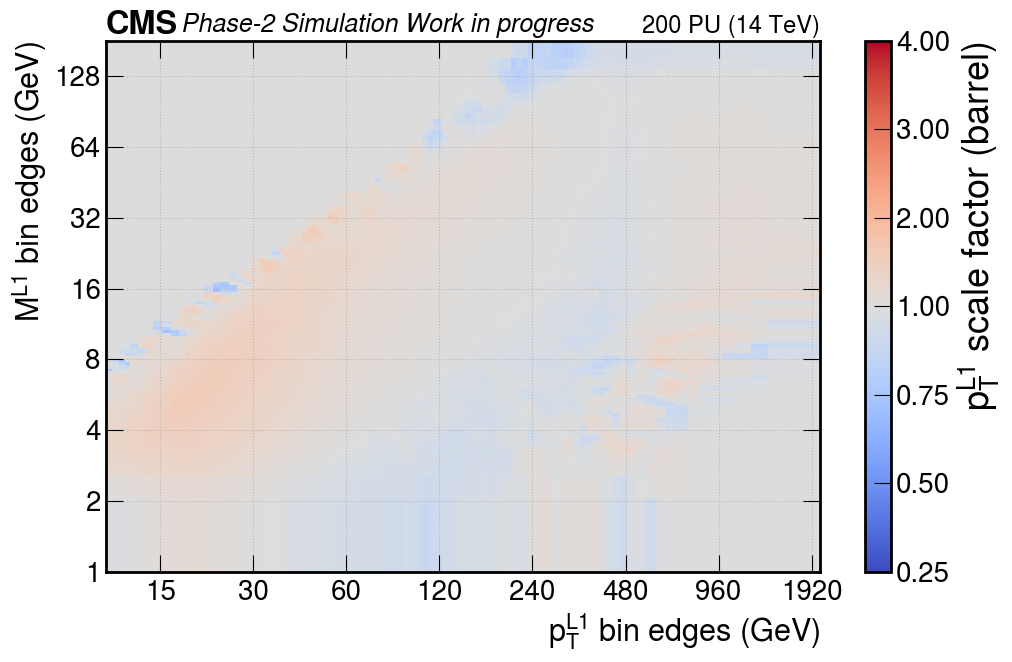

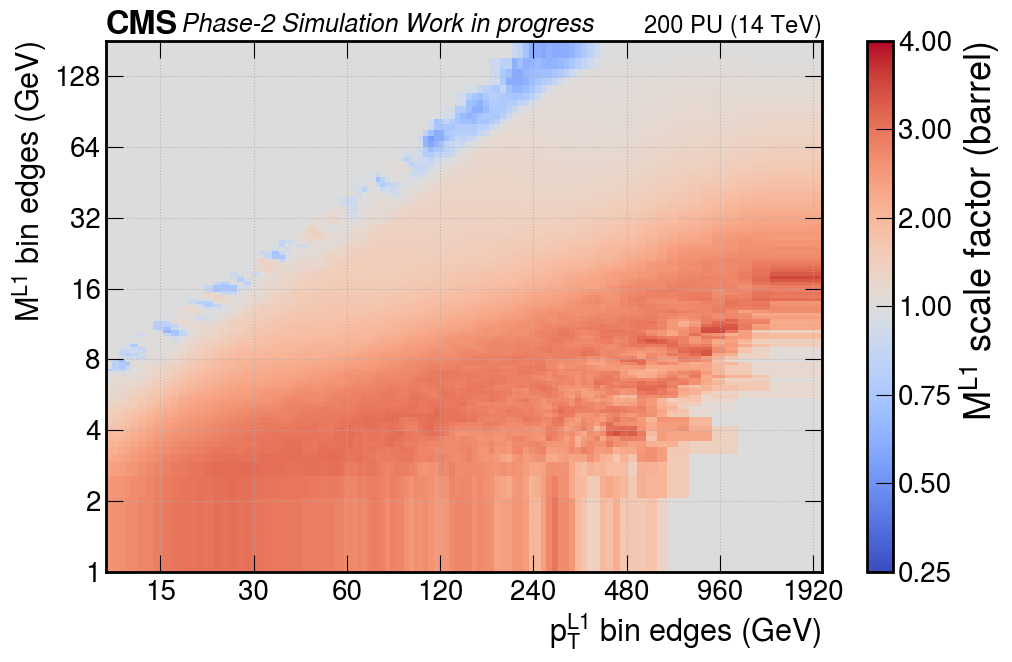

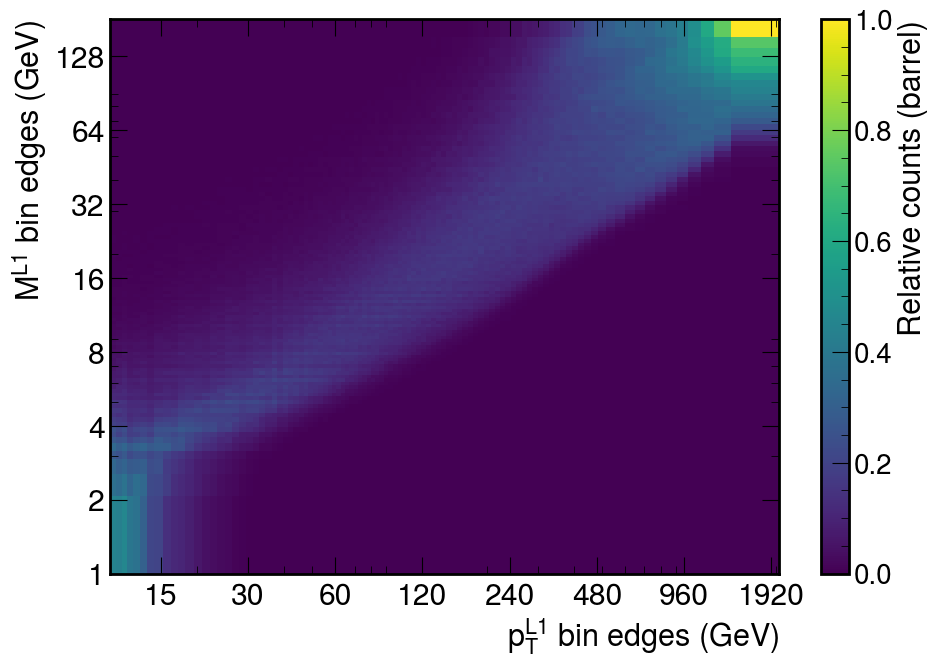

In [7]:
# Get scale factor for each bin and the bin edges (and counts)
pt_sf, mass_sf, bin_edges, counts = histo.histogram(train)
plot_scale_factors.HistoScaleFactors(bin_edges, counts, pt=pt_sf, mass=mass_sf)

In [8]:
params = {
    "booster": "gbtree",
    "learning_rate": 0.8,
    "max_depth": 6,
    "verbosity": 1,
    "validate_parameters": True,
}

# train = bdt.get_targets(train)
# train = bdt.get_weights(train)
model = bdt.train(train, target="pt")

Using custom loss function!


In [11]:
!pip install torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 888.0/888.0 MB ?  0:00:454.8 MB/s eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 19.9 MB/s  0:00:14 eta 0:00:010:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 74.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 91.6 MB/s  0:00:00s eta 0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 48.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 9.9 MB/s  0:00:28s eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 98.2 MB/s  0:00:01 eta 0:00:010:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 61.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 47.6 MB/s  0:00:01s eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 26.9 MB/s  0:00:09 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 MB 23.2 MB/s  0:00:11 eta 0:00:010:00:01
 

In [9]:
pts = np.linspace(0, 2048, 2049)
masses = np.linspace(0, 182, 183)
etas = np.linspace(-1.5, 1.5, 6)
import xgboost as xgb
xgb.DMatrix(np.meshgrid(pts, masses, etas))

ValueError: Please reshape the input data into 2-dimensional matrix.

{'pt': 164.31236267089844, 'mass': 49.852691650390625, 'eta': 45.007869720458984}


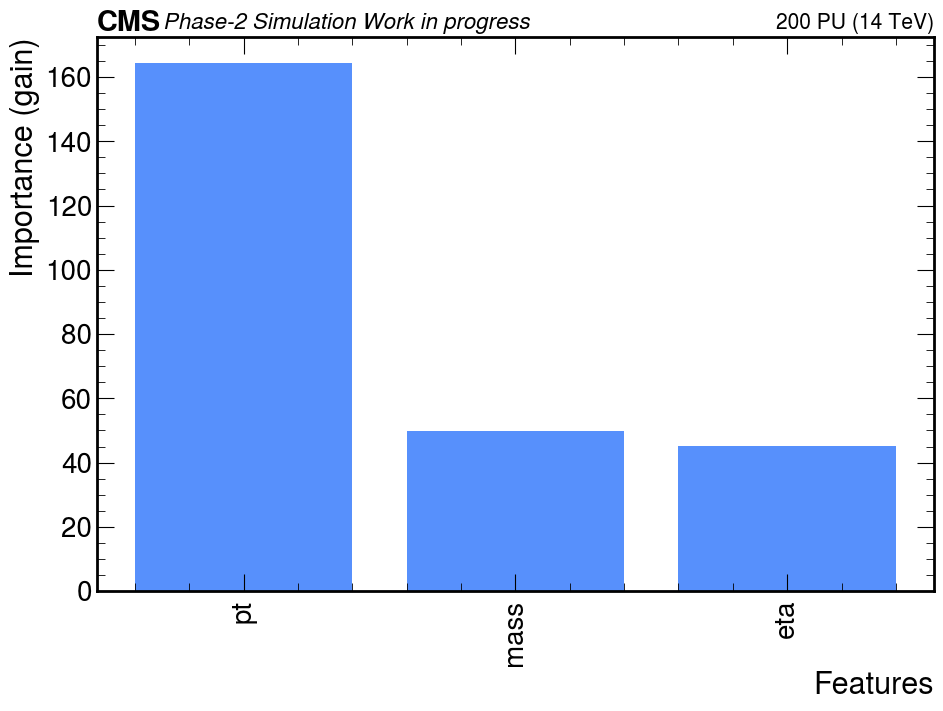

In [ ]:
plot_scale_factors.BDTScaleFactors(model)

# Prototyping a NN

In [27]:
import torch
from torch.utils.data import TensorDataset, DataLoader, random_split
from tqdm import tqdm
import matplotlib.pyplot as plt

In [ ]:
train["pt_sfs"] = 1/train["pt_response"]
train["mass_sfs"] = 1/train["mass_response"]

def make_loaders(data, features = ["pt", "mass", "eta"], targets=["pt_sfs", "mass_sfs"], val_frac: int = 0.0, batchsize = 256):

    X = torch.tensor(data[features].values, dtype=torch.float32)
    y = torch.tensor(data[targets].values, dtype=torch.float32)
    dataset = TensorDataset(X, y)

    val_size = int(len(dataset) * val_frac)
    train_size = len(dataset) - val_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_dataset, batch_size=batchsize, shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=batchsize, shuffle=False)
    
    return train_dataset, train_loader, val_dataset, val_loader

In [54]:
train_dataset, train_loader, val_dataset, val_loader = make_loaders(train)

In [47]:
class Model(torch.nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.batchnorm = torch.nn.BatchNorm1d(num_features=3)
        self.fc1 = torch.nn.Linear(in_features=3, out_features=64)
        self.fc2 = torch.nn.Linear(in_features=64, out_features=64)
        self.fc3 = torch.nn.Linear(in_features=64, out_features=32)
        self.fc4 = torch.nn.Linear(in_features=32, out_features=2)
        self.relu = torch.nn.ReLU()

    def forward(self, x):
        x = self.batchnorm(x)
        x = self.relu(self.fc1(x))           # (batch, 6)
        x = self.relu(self.fc2(x))           # (batch, 12)
        x = self.relu(self.fc3(x))           # (batch, 6)
        x = self.fc4(x)                      # (batch, 2)
        return x
    
model = Model()

In [48]:
loss_fn = torch.nn.HuberLoss(delta = 0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [49]:
early_stopping = True
patience = 5
wait = 0
best_val_loss = np.inf

train_losses, val_losses = [], []
for epoch in tqdm(range(10)):
    model.train()
    train_loss = 0
    for x, y in train_loader:
        optimizer.zero_grad()
        y_pred = model(x)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item() * x.size(0)
        loss.backward()
        optimizer.step()
    train_loss /= len(train_dataset)

    # At the end of each epoch do evaluation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb_val, yb_val in val_loader:
            pred_val = model(xb_val)
            val_loss += loss_fn(pred_val, yb_val).item() * xb_val.size(0)    # we multiply by batch size as some batches are smaller than others
    val_loss /= len(val_dataset)    # get average validation loss

    print(f"Epoch {epoch} | train_loss = {train_loss:.4f} | val_loss = {val_loss:.4f}")
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if early_stopping:
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            wait = 0
            torch.save(model.state_dict(), "best_model.pt")  # save best weights
        else:
            wait += 1
            if wait >= patience:
                print(f"Stopping early at epoch {epoch}")
                break

  0%|                                                                                                                                                                        | 0/10 [00:00<?, ?it/s]

 10%|████████████████                                                                                                                                                | 1/10 [00:40<06:06, 40.74s/it]

Epoch 0 | train_loss = 0.0364 | val_loss = 0.0356
Epoch 1 | train_loss = 0.0359 | val_loss = 0.0354


 20%|████████████████████████████████                                                                                                                                | 2/10 [01:21<05:26, 40.81s/it]

Epoch 2 | train_loss = 0.0359 | val_loss = 0.0354


...

Epoch 7 | train_loss = 0.0358 | val_loss = 0.0354


 90%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                | 9/10 [06:27<00:45, 45.13s/it]

Epoch 8 | train_loss = 0.0358 | val_loss = 0.0354


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [07:14<00:00, 43.49s/it]

Epoch 9 | train_loss = 0.0358 | val_loss = 0.0354


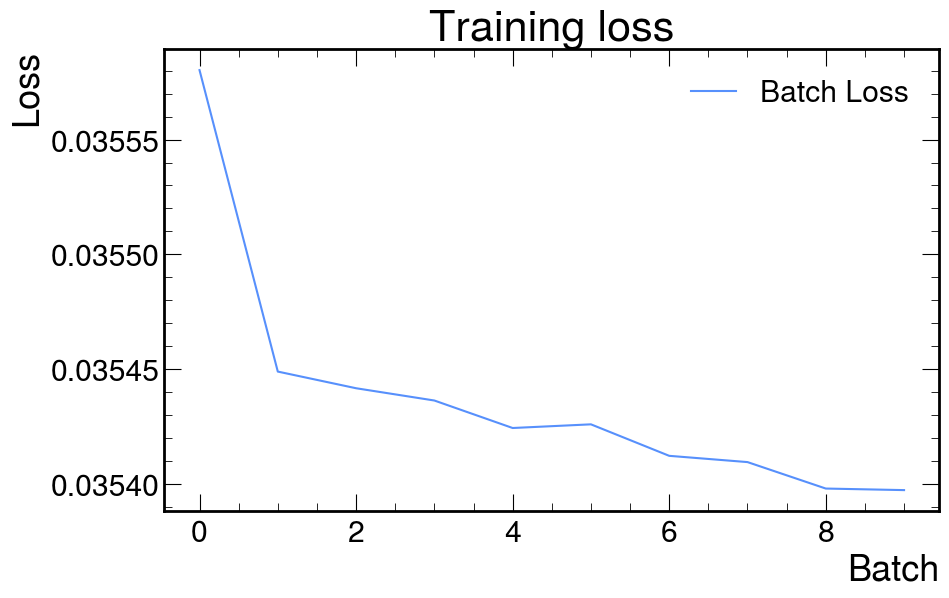

In [52]:
def plot_loss():
    plt.figure(figsize=(10,6))
    plt.plot(val_losses, label="Batch Loss")
    plt.xlabel("Batch")
    plt.ylabel("Loss")
    plt.title("Training loss")
    plt.legend()
    plt.show()

plot_loss()

In [18]:
X_test = torch.tensor(test[features].values, dtype=torch.float32)

In [19]:
model.eval()
with torch.no_grad():
    pred = model(X_test).numpy()
pred

array([[1.0269139, 1.1092883],
       [1.0379969, 1.2220888],
       [1.2957044, 1.6547428],
       ...,
       [1.0604713, 2.018602 ],
       [1.2669818, 2.156621 ],
       [1.0202352, 3.0173697]], dtype=float32)

In [20]:
pt_sfs, mass_sfs = np.clip(pred[:,0], 0.25, 4), np.clip(pred[:,1], 0.25, 4)

In [21]:
test["pt_corr"] = pt_sfs * test["pt"]
test["mass_corr"] = mass_sfs * test["mass"]

In [22]:
test["pt_resp"] = test["pt_response"]
test["pt_resp_corr"] = test["pt_corr"] / test["genpt"]
test["mass_resp"] = test["mass_response"]
test["mass_resp_corr"] = test["mass_corr"] / test["genmass"]

/dice/users/wq22321/jet_mass_corrections/.env/lib64/python3.9/site-packages/numpy/linalg/_linalg.py:2371: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
/dice/users/wq22321/jet_mass_corrections/plotting/plot_resolutions.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


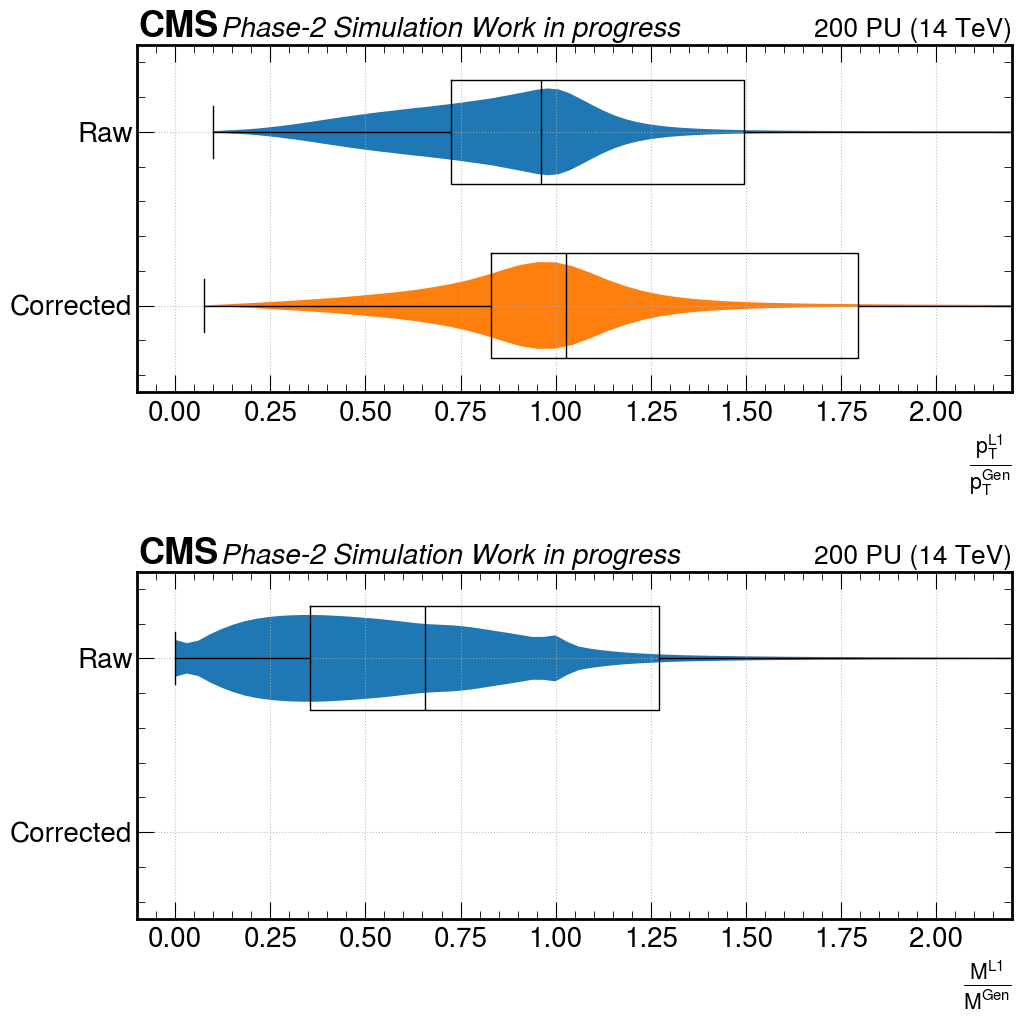

/dice/users/wq22321/jet_mass_corrections/.env/lib64/python3.9/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


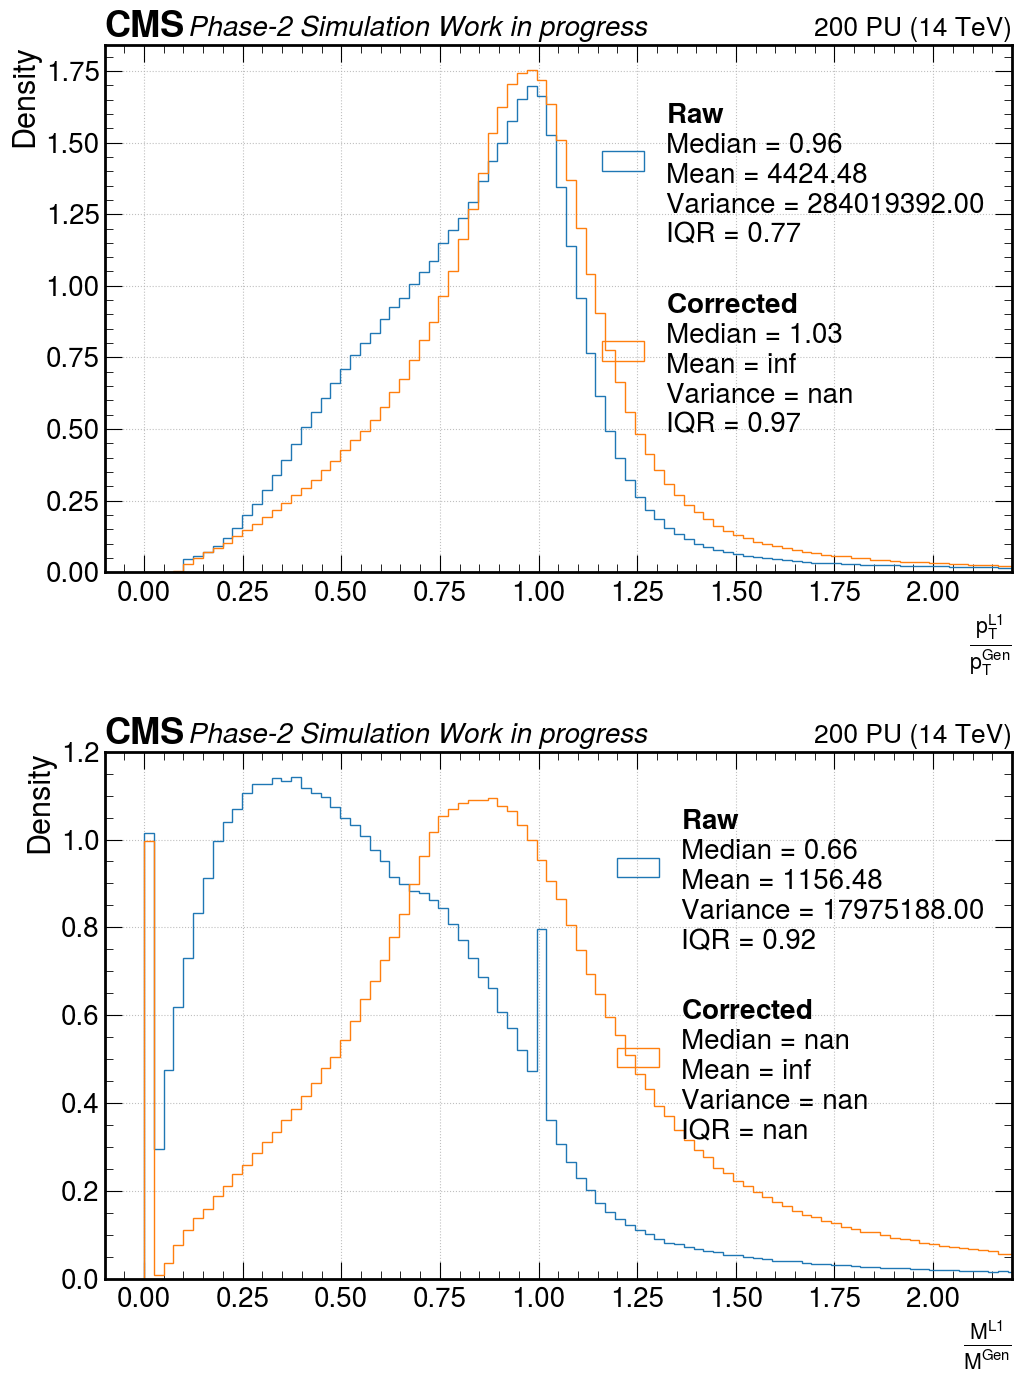

/dice/users/wq22321/jet_mass_corrections/.env/lib64/python3.9/site-packages/numpy/lib/_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


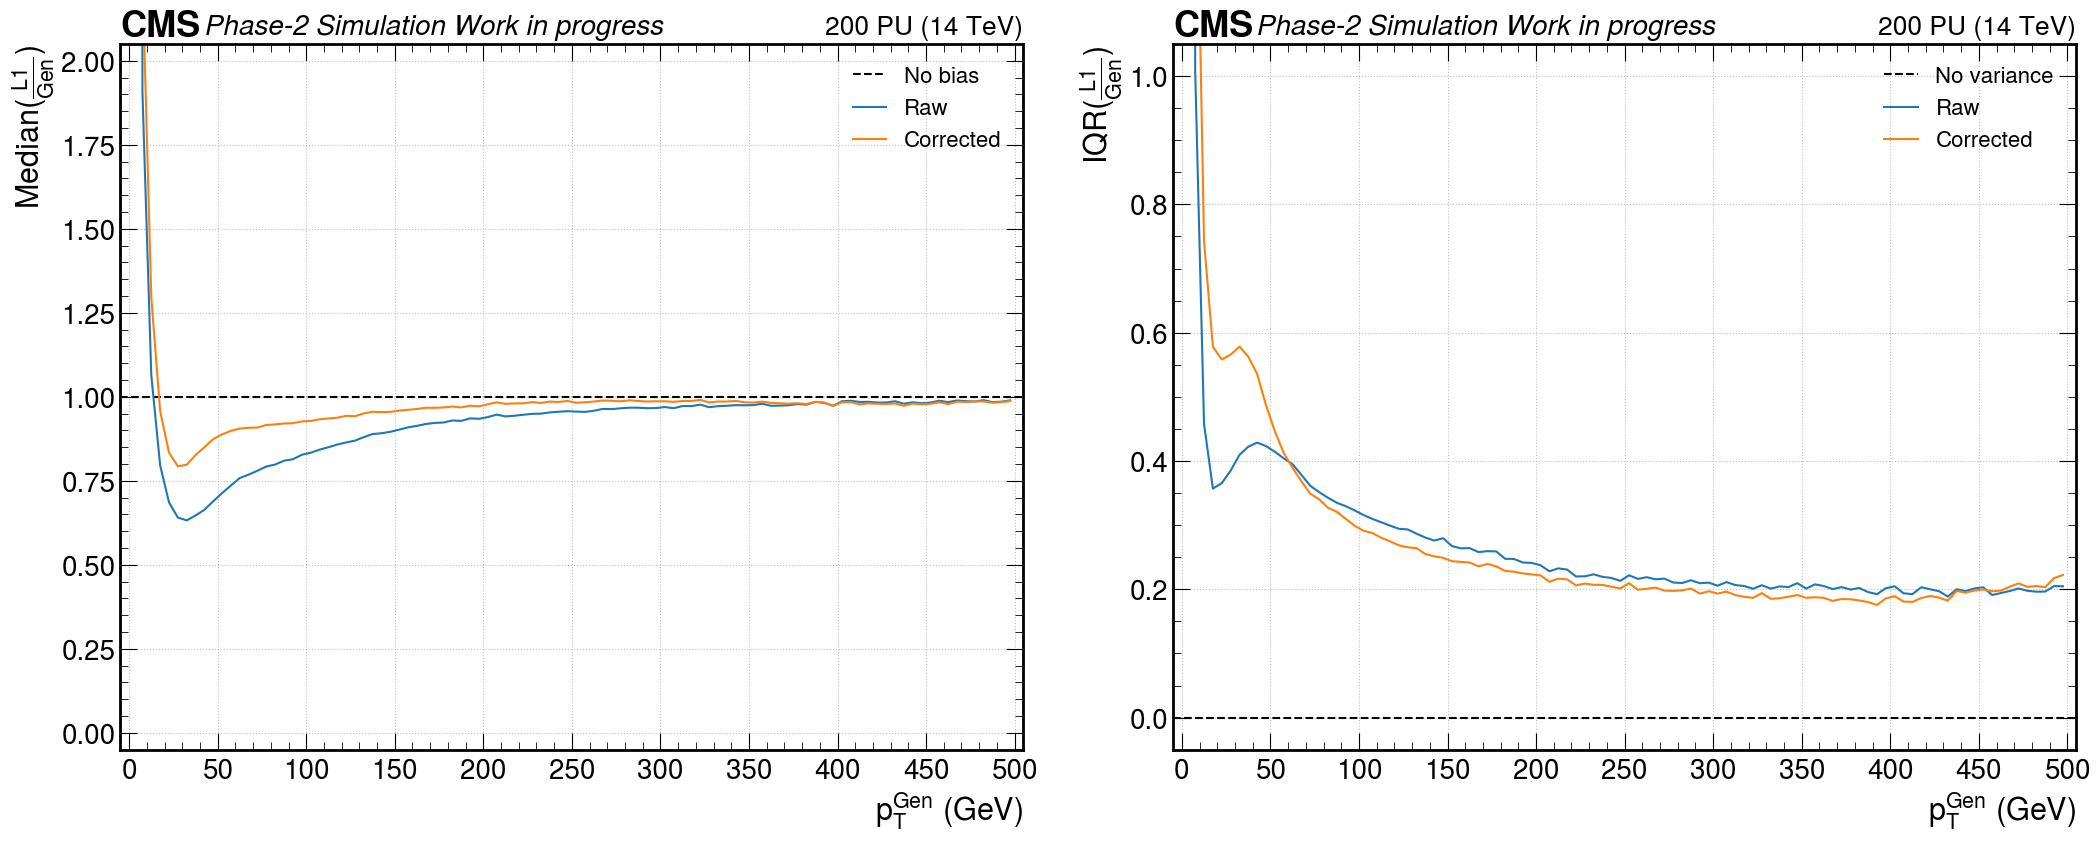

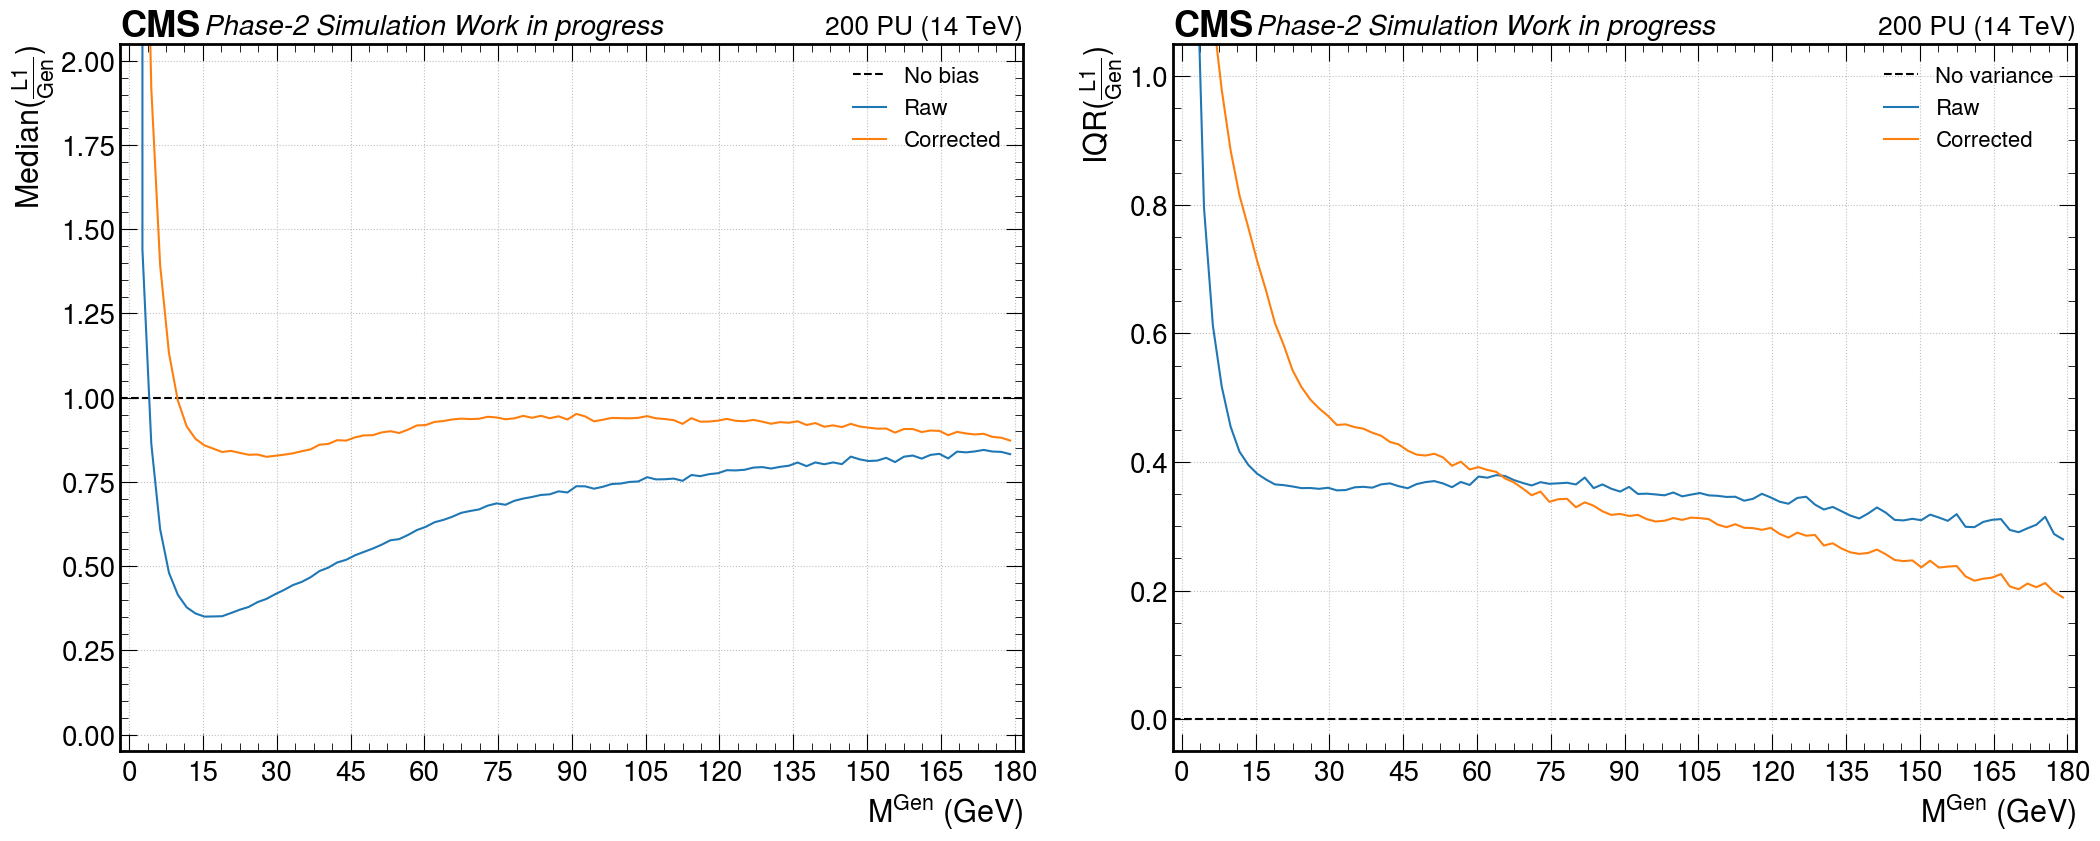

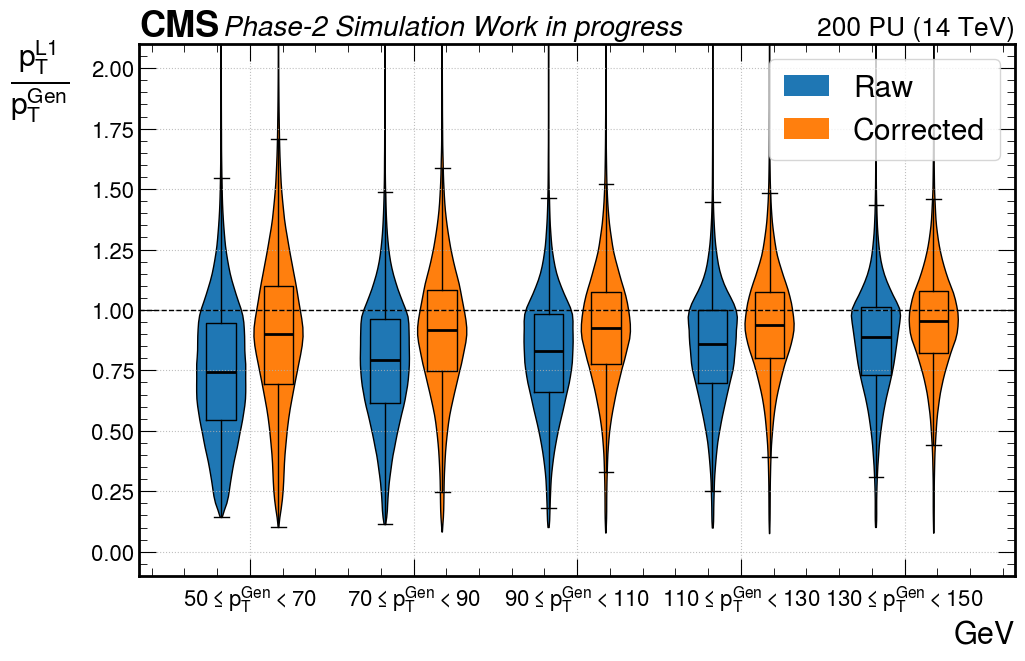

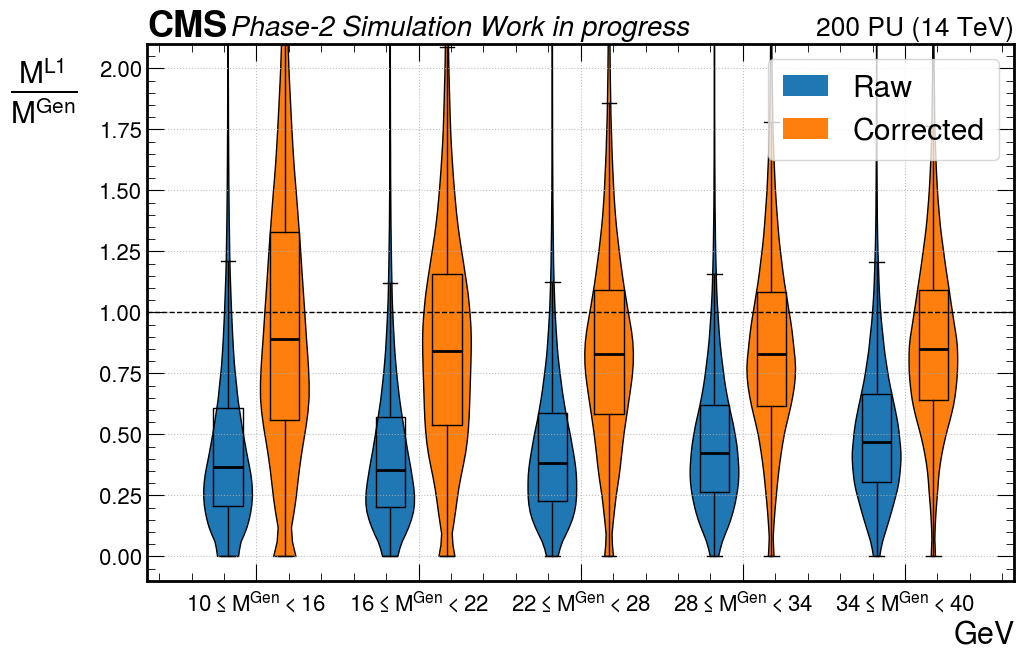

AttributeError: 'DataFrame' object has no attribute 'pt_response_corr'

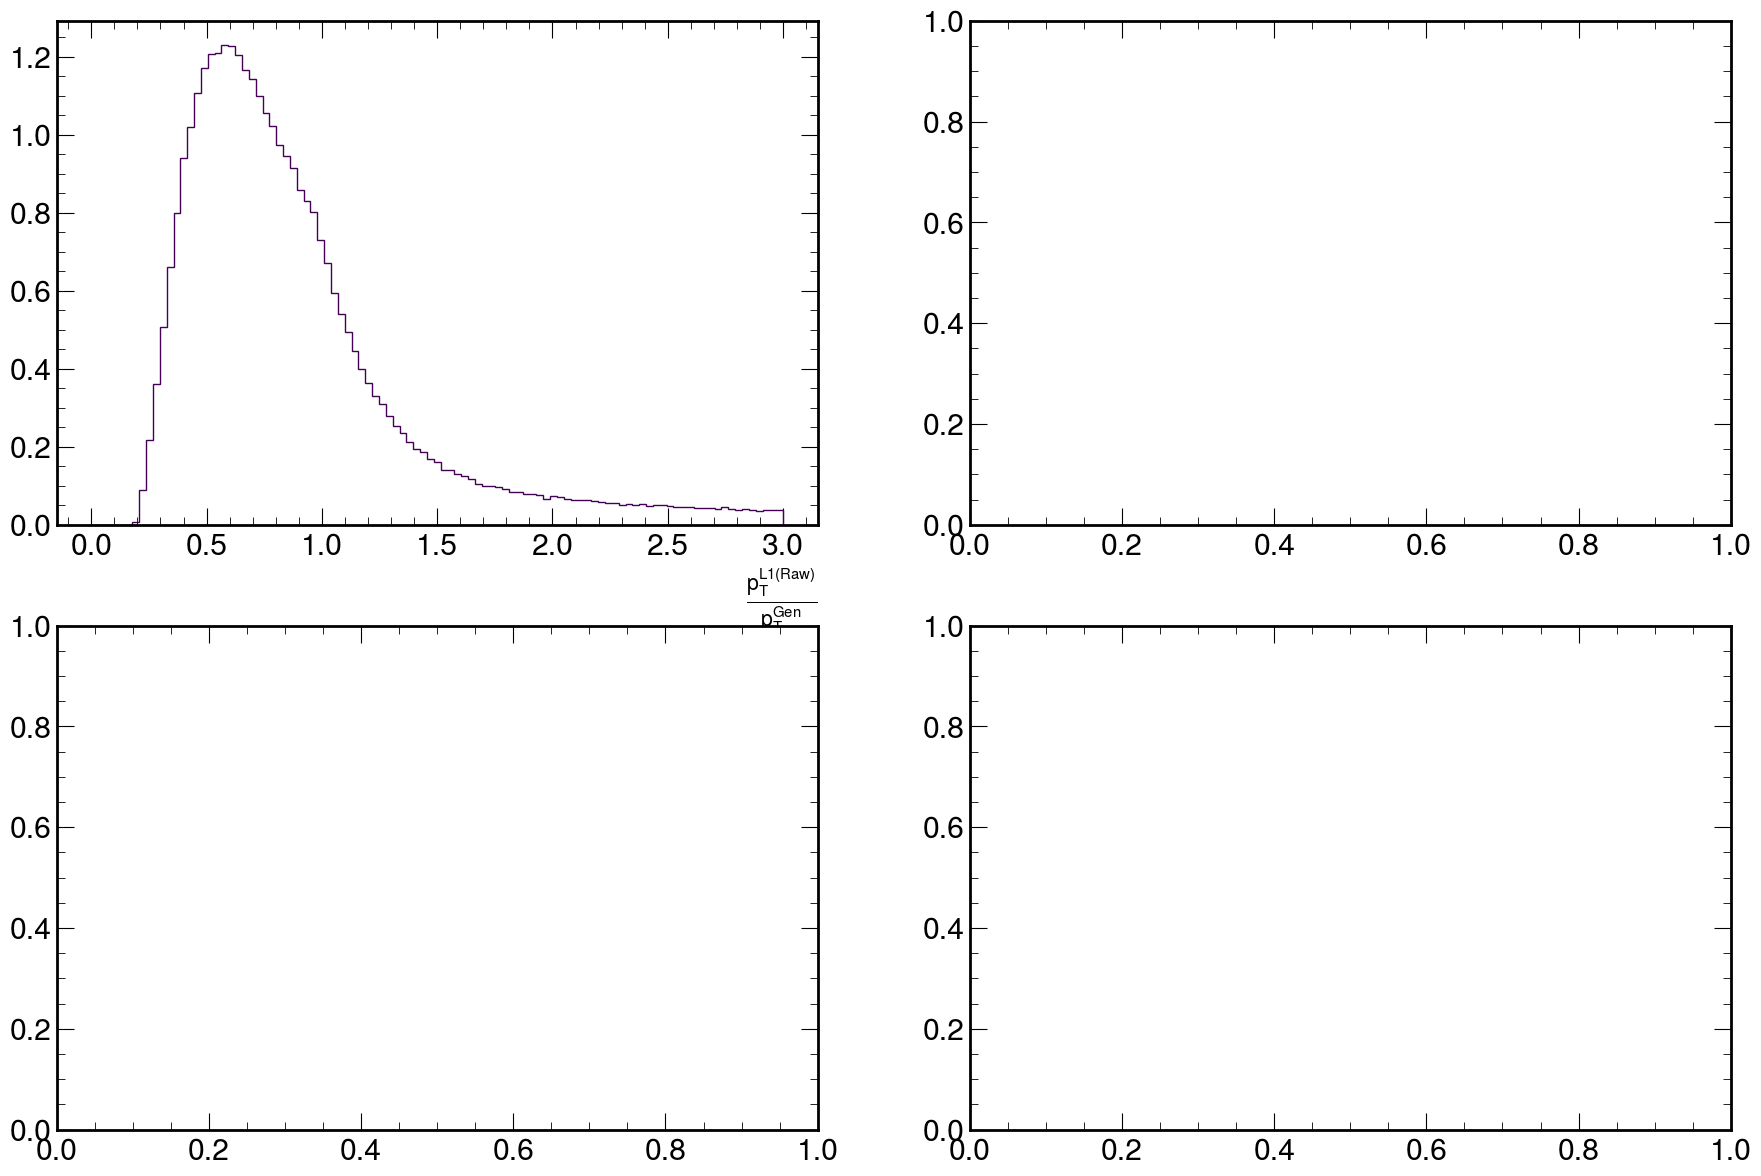

In [23]:
from plotting.plot_resolutions import *
plot_all(test)

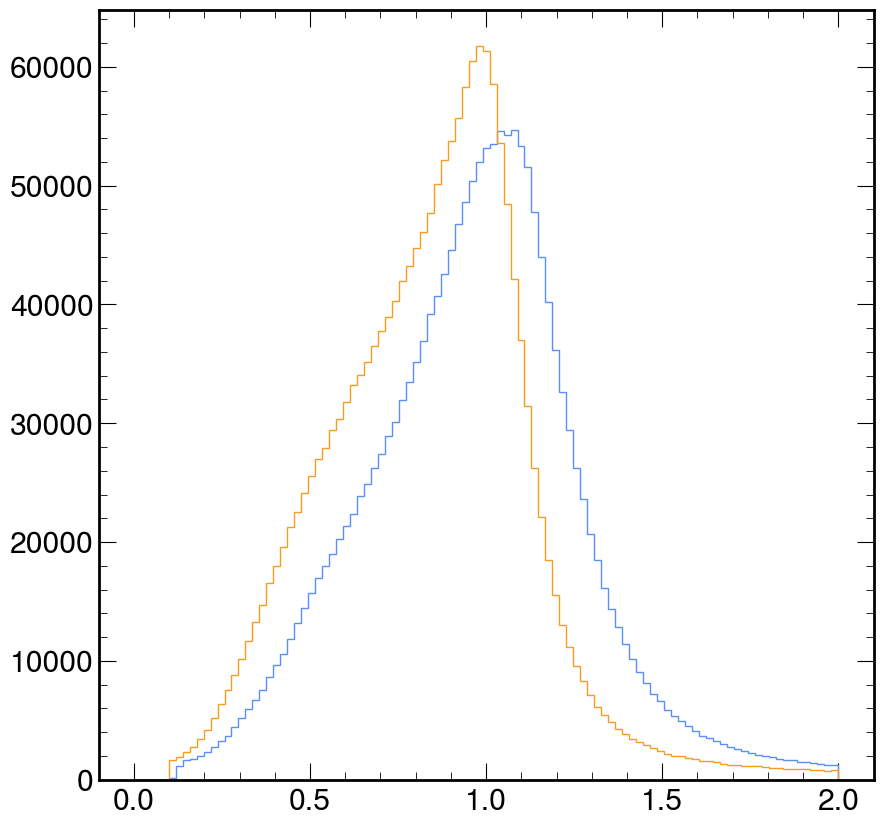

In [114]:
plt.hist( test.pt_corr / test.genpt, bins=101, range=[0,2], histtype="step" )
plt.hist( test.pt / test.genpt, bins=101, range=[0,2], histtype="step")
plt.show()